# WikiFactDiff Dataset Exploration

This notebook explores the WikiFactDiff dataset, which we will use as the source of explicit
contradiction pairs for the **Contradiction-Aware Sparse Memory Finetuning (CASF)** continual
learning project.

## Why WikiFactDiff?

TemporalWiki's TWiki-Probes only store the **new** fact after a Wikidata update — the old fact
value is never recorded. This means we cannot reconstruct `(old_object → new_object)` contradiction
pairs from TemporalWiki alone.

WikiFactDiff was explicitly built to fill this gap. It compares two Wikidata snapshots at:
- **T_old** = 4 January 2021
- **T_new** = 27 February 2023

and labels each fact as `new`, `obsolete`, or `static`. Replacement updates (`is_replace=True`)
give us exact `(old_object → new_object)` pairs — the contradiction signal CASF needs.

## What We Want to Understand

1. What does the schema look like — what fields are available?
2. How many records are replacements vs new entities vs static?
3. What do replacement contradiction pairs look like?
4. What relations appear most frequently in replacements?
5. What do the verbalization templates and cloze tests look like?
6. What does the neighborhood / bleedover structure look like?
7. How many clean contradiction pairs do we have for CASF training?

## Setup

Install dependencies using [uv](https://github.com/astral-sh/uv):

```bash
uv pip install pandas matplotlib pyarrow
```

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
import os

print("pandas:", pd.__version__)

PARQUET_PATH = "data/wikifactdiff/train.parquet"
assert os.path.exists(PARQUET_PATH), f"Missing {PARQUET_PATH} — run download_wikifactdiff.py first"
print("Parquet file found.")

pandas: 2.3.3
Parquet file found.


## 1. Load the Dataset

In [20]:
df = pd.read_parquet(PARQUET_PATH)
print(f"Total records: {len(df):,}")
print(f"Columns: {list(df.columns)}")

Total records: 327,688
Columns: ['subject', 'relation', 'update_prompt', 'generalization_prompts', 'subject_is_ph_new', 'relation_is_temp_func', 'is_replace', 'subject_popularity', 'objects', 'neighborhood']


In [21]:
# Inspect a single record in full
sample = df.iloc[0]
for col in df.columns:
    print(f"\n--- {col} ---")
    print(sample[col])


--- subject ---
{'description': 'artificial intelligence chatbot developed by OpenAI', 'id': 'Q115564437', 'label': 'ChatGPT'}

--- relation ---
{'description': 'that class of which this subject is a particular example and member; different from P279 (subclass of); for example: K2 is an instance of mountain; volcano is a subclass of mountain (and an instance of volcanic landform)', 'id': 'P31', 'label': 'instance of'}

--- update_prompt ---
ChatGPT is an example of a ____

--- generalization_prompts ---
['ChatGPT is a ____' 'ChatGPT is a type of ____'
 'ChatGPT belongs to the class of ____'
 'ChatGPT falls under the category of ____']

--- subject_is_ph_new ---
True

--- relation_is_temp_func ---
False

--- is_replace ---
False

--- subject_popularity ---
15.100925597859858

--- objects ---
[{'decision': 'new', 'description': 'statistical model of structure of language', 'id': 'Q3621696', 'label': 'language model'}
 {'decision': 'new', 'description': 'program or set of instructions th

## 2. High-Level Flag Distribution

The two most important boolean flags for CASF:
- `is_replace` — the subject-relation pair had one object at T_old and a different one at T_new (contradiction pair)
- `subject_is_ph_new` — the subject entity didn't exist at T_old (brand new entity, no contradiction)

In [22]:
print("is_replace distribution:")
print(df['is_replace'].value_counts())
print(f"  → {df['is_replace'].sum():,} replacement records ({100*df['is_replace'].mean():.1f}%)")

print("\nsubject_is_ph_new distribution:")
print(df['subject_is_ph_new'].value_counts())
print(f"  → {df['subject_is_ph_new'].sum():,} brand-new entities ({100*df['subject_is_ph_new'].mean():.1f}%)")

print("\nrelation_is_temp_func distribution:")
print(df['relation_is_temp_func'].value_counts())
print(f"  → {df['relation_is_temp_func'].sum():,} temporal function relations ({100*df['relation_is_temp_func'].mean():.1f}%)")

is_replace distribution:
is_replace
False    294815
True      32873
Name: count, dtype: int64
  → 32,873 replacement records (10.0%)

subject_is_ph_new distribution:
subject_is_ph_new
False    194831
True     132857
Name: count, dtype: int64
  → 132,857 brand-new entities (40.5%)

relation_is_temp_func distribution:
relation_is_temp_func
False    299850
True      27838
Name: count, dtype: int64
  → 27,838 temporal function relations (8.5%)


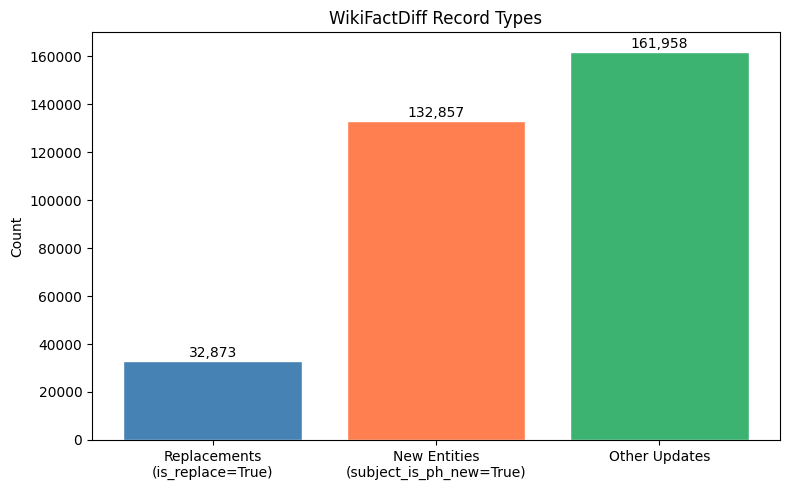

In [23]:
# Visualise the three key splits
replace_count    = df['is_replace'].sum()
new_entity_count = (~df['is_replace'] & df['subject_is_ph_new']).sum()
other_count      = (~df['is_replace'] & ~df['subject_is_ph_new']).sum()

labels = ['Replacements\n(is_replace=True)', 'New Entities\n(subject_is_ph_new=True)', 'Other Updates']
counts = [replace_count, new_entity_count, other_count]
colors = ['steelblue', 'coral', 'mediumseagreen']

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts, color=colors, edgecolor='white')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{count:,}', ha='center', va='bottom', fontsize=10)
plt.title("WikiFactDiff Record Types")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 3. Extract Replacement Contradiction Pairs

For CASF, we need records where `is_replace=True`. These have at least one `obsolete` object
(the old fact) and one `new` object (the new fact) under the same `(subject, relation)`.

In [24]:
replacements = df[df['is_replace'] == True].copy()
print(f"Replacement records: {len(replacements):,}")
print()

# Helper — objects comes back as a numpy array of dicts from parquet
# Each element may be a numpy void, so convert to plain dict before access
def get_objects_by_decision(objects, decision):
    results = []
    for o in objects:
        o = dict(o)
        if o.get('decision') != decision:
            continue
        label = o.get('label')
        if label:
            results.append(label)
    return results

# Show 5 examples
for i, row in replacements.head(5).iterrows():
    subject_label  = row['subject']['label']
    relation_label = row['relation']['label']
    old_objects    = get_objects_by_decision(row['objects'], 'obsolete')
    new_objects    = get_objects_by_decision(row['objects'], 'new')

    print(f"Subject  : {subject_label}")
    print(f"Relation : {relation_label}")
    print(f"Old fact : {old_objects}")
    print(f"New fact : {new_objects}")
    print(f"Cloze    : {row['update_prompt']}")
    print()

Replacement records: 32,873

Subject  : United States of America
Relation : head of government
Old fact : ['Donald Trump']
New fact : ['Joe Biden']
Cloze    : United States of America's head of government is ____

Subject  : Cristiano Ronaldo
Relation : league
Old fact : ['Premier League']
New fact : ['Saudi Professional League']
Cloze    : Cristiano Ronaldo played in the ____

Subject  : India
Relation : head of state
Old fact : ['Ram Nath Kovind']
New fact : ['Droupadi Murmu']
Cloze    : India's head of state is ____

Subject  : United Kingdom
Relation : head of government
Old fact : ['Boris Johnson']
New fact : ['Rishi Sunak']
Cloze    : United Kingdom's head of government is ____

Subject  : United Kingdom
Relation : head of state
Old fact : ['Elizabeth II']
New fact : ['Charles III']
Cloze    : United Kingdom's head of state is ____



In [25]:
# Build a clean contradiction pairs dataframe
# Uses the get_objects_by_decision helper defined above
pairs = []
for _, row in replacements.iterrows():
    subject_label  = row['subject']['label']
    relation_label = row['relation']['label']
    relation_desc  = row['relation'].get('description', '')

    old_objects = get_objects_by_decision(row['objects'], 'obsolete')
    new_objects = get_objects_by_decision(row['objects'], 'new')

    if old_objects and new_objects:
        pairs.append({
            'subject':               subject_label,
            'relation':              relation_label,
            'relation_desc':         relation_desc,
            'old_object':            old_objects[0],
            'new_object':            new_objects[0],
            'update_prompt':         row['update_prompt'],
            'subject_popularity':    row['subject_popularity'],
            'relation_is_temp_func': row['relation_is_temp_func'],
        })

pairs_df = pd.DataFrame(pairs)
print(f"Clean contradiction pairs: {len(pairs_df):,}")
print(f"(Records with both old and new object labels resolved)")
print()
print(pairs_df.head(10).to_string(index=False))

Clean contradiction pairs: 32,873
(Records with both old and new object labels resolved)

                 subject           relation                                                                                                                                                                                                               relation_desc          old_object                new_object                                         update_prompt  subject_popularity  relation_is_temp_func
United States of America head of government                                                                                                                    head of the executive power of this town, city, municipality, state, country, or other governmental body        Donald Trump                 Joe Biden United States of America's head of government is ____           14.192023                  False
       Cristiano Ronaldo             league                                                     

## 4. Relation Distribution in Replacement Pairs

Which relations change most frequently? This matters for CASF — high-frequency changing
relations (like `head of state`, `member of sports team`) are where contradiction-awareness
will have the most impact.

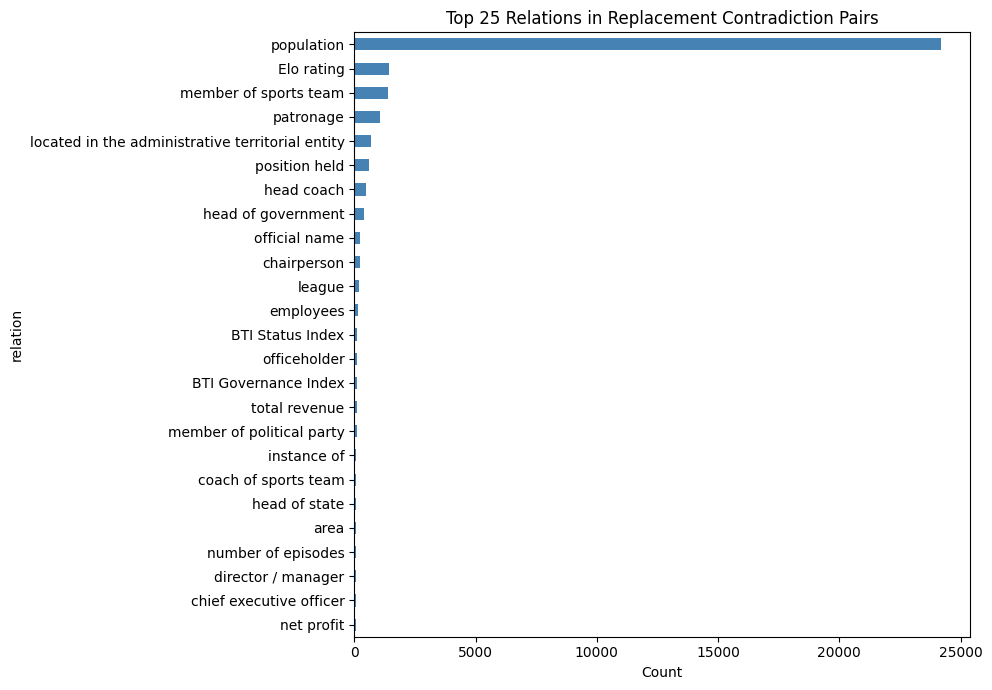


Total unique relations in replacements: 157
Top 5:
  population: 24,189
  Elo rating: 1,419
  member of sports team: 1,405
  patronage: 1,046
  located in the administrative territorial entity: 694


In [26]:
relation_counts = pairs_df['relation'].value_counts().head(25)

plt.figure(figsize=(10, 7))
relation_counts.plot(kind='barh', color='steelblue')
plt.title("Top 25 Relations in Replacement Contradiction Pairs")
plt.xlabel("Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal unique relations in replacements: {pairs_df['relation'].nunique()}")
print(f"Top 5:")
for rel, count in relation_counts.head(5).items():
    print(f"  {rel}: {count:,}")

In [27]:
# Temporal function relations vs non-temporal
temp_func = pairs_df['relation_is_temp_func'].value_counts()
print("Temporal function relations in replacement pairs:")
print(temp_func)
print(f"\nTemporal functions are relations that change over time by definition")
print(f"(e.g. 'head of state', 'population', 'rank') — high signal for CASF")

Temporal function relations in replacement pairs:
relation_is_temp_func
True     27684
False     5189
Name: count, dtype: int64

Temporal functions are relations that change over time by definition
(e.g. 'head of state', 'population', 'rank') — high signal for CASF


## 5. Verbalization Templates & Cloze Tests

WikiFactDiff provides pre-built cloze tests (`update_prompt`) and generalization prompts.
These are how we can evaluate whether a model has learned the new fact.

In [28]:
# Show update_prompt and generalization_prompts for a few replacement records
for i, row in replacements.head(5).iterrows():
    subject_label = row['subject']['label'] if isinstance(row['subject'], dict) else row['subject']
    relation_label = row['relation']['label'] if isinstance(row['relation'], dict) else row['relation']
    
    print(f"Subject  : {subject_label}")
    print(f"Relation : {relation_label}")
    print(f"update_prompt        : {row['update_prompt']}")
    print(f"generalization_prompts:")
    for p in row['generalization_prompts'][:3]:
        print(f"  - {p}")
    print()

Subject  : United States of America
Relation : head of government
update_prompt        : United States of America's head of government is ____
generalization_prompts:
  - The head of government of United States of America is ____
  - United States of America is governed by ____
  - The position of head of government in United States of America is held by ____

Subject  : Cristiano Ronaldo
Relation : league
update_prompt        : Cristiano Ronaldo played in the ____
generalization_prompts:
  - Cristiano Ronaldo participated in the ____
  - Cristiano Ronaldo plays in the ____
  - Cristiano Ronaldo was a player in the ____

Subject  : India
Relation : head of state
update_prompt        : India's head of state is ____
generalization_prompts:
  - The head of state of India is ____
  - India's highest formal authority is ____
  - The position of head of state in India is held by ____

Subject  : United Kingdom
Relation : head of government
update_prompt        : United Kingdom's head of gove

## 6. Neighborhood / Bleedover Structure

Each record includes a `neighborhood` — nearby facts used to check whether a model edit
bleeds into unrelated facts. This is critical for evaluating CASF locality.

In [29]:
# Inspect neighborhood structure for one replacement record
sample_row = replacements.iloc[0]
subject_label = sample_row['subject']['label'] if isinstance(sample_row['subject'], dict) else sample_row['subject']

print(f"Subject: {subject_label}")
print(f"Neighborhood size: {len(sample_row['neighborhood'])} neighbors")
print()

for neighbor in sample_row['neighborhood'][:3]:
    print(f"  dist: {neighbor['dist']:.4f}")
    print(f"  objects: {neighbor['objects'][:2]}")
    print()

# Distribution of neighborhood sizes
neighborhood_sizes = df['neighborhood'].apply(len)
print(f"Neighborhood size stats:")
print(neighborhood_sizes.describe())

Subject: United States of America
Neighborhood size: 10 neighbors

  dist: 0.6845
  objects: [{'object': {'description': 'Prime Minister of France', 'id': 'Q3171170', 'label': 'Jean Castex'}, 'prompt': 'The position of head of government in France is held by ____'}]

  dist: 0.7233
  objects: [{'object': {'description': 'Prime Minister of the United Kingdom from 2019 to 2022', 'id': 'Q180589', 'label': 'Boris Johnson'}, 'prompt': 'The position of head of government in United Kingdom is held by ____'}]

  dist: 0.7245
  objects: [{'object': {'description': 'premier of China since 2013', 'id': 'Q18111', 'label': 'Li Keqiang'}, 'prompt': "People's Republic of China is governed by ____"}]

Neighborhood size stats:
count    327688.000000
mean          9.033684
std          39.320273
min           0.000000
25%           0.000000
50%          10.000000
75%          10.000000
max        1802.000000
Name: neighborhood, dtype: float64


## 7. Subject Popularity Distribution

Subject popularity is a float measuring how prominent an entity is in Wikipedia.
Higher popularity = more likely the model has seen this entity during pretraining,
making it a better test of whether the model actually knew the old fact.

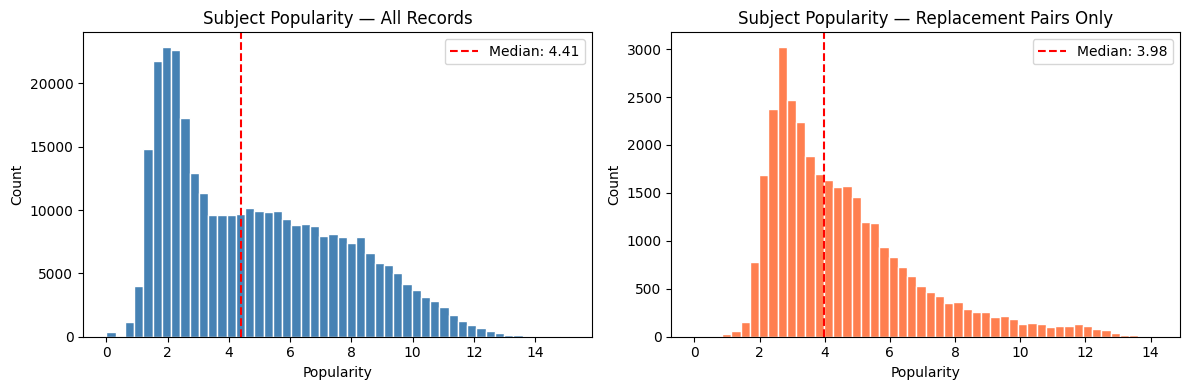

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# All records
axes[0].hist(df['subject_popularity'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title("Subject Popularity — All Records")
axes[0].set_xlabel("Popularity")
axes[0].set_ylabel("Count")
axes[0].axvline(df['subject_popularity'].median(), color='red', linestyle='--',
                label=f"Median: {df['subject_popularity'].median():.2f}")
axes[0].legend()

# Replacement pairs only
axes[1].hist(pairs_df['subject_popularity'], bins=50, color='coral', edgecolor='white')
axes[1].set_title("Subject Popularity — Replacement Pairs Only")
axes[1].set_xlabel("Popularity")
axes[1].set_ylabel("Count")
axes[1].axvline(pairs_df['subject_popularity'].median(), color='red', linestyle='--',
                label=f"Median: {pairs_df['subject_popularity'].median():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Objects Decision Label Breakdown

Each record has a list of `objects`, each labeled `new`, `obsolete`, or `static`.
Let's understand how many objects per record and what the decision distribution looks like.

In [31]:
# Count decision labels across all records
decision_counts = Counter()
objects_per_record = []

for objects in df['objects']:
    objects_per_record.append(len(objects))
    for obj in objects:
        decision_counts[obj['decision']] += 1

print("Decision label counts across all object entries:")
for label, count in decision_counts.most_common():
    print(f"  {label}: {count:,}")

print(f"\nObjects per record:")
opr = pd.Series(objects_per_record)
print(opr.describe())

Decision label counts across all object entries:
  new: 410,449
  obsolete: 39,384
  static: 4,532

Objects per record:
count    327688.000000
mean          1.386578
std           3.770350
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         306.000000
dtype: float64


In [32]:
# For replacement pairs specifically, how many have exactly 1 old and 1 new object?
clean = 0
multi_old = 0
multi_new = 0

for _, row in replacements.iterrows():
    n_old = len(get_objects_by_decision(row['objects'], 'obsolete'))
    n_new = len(get_objects_by_decision(row['objects'], 'new'))
    if n_old == 1 and n_new == 1:
        clean += 1
    elif n_old > 1:
        multi_old += 1
    elif n_new > 1:
        multi_new += 1

print(f"Replacement records with exactly 1 old + 1 new object : {clean:,}")
print(f"Replacement records with multiple old objects          : {multi_old:,}")
print(f"Replacement records with multiple new objects          : {multi_new:,}")
print(f"\nClean 1:1 pairs are the simplest contradiction signal for CASF")

Replacement records with exactly 1 old + 1 new object : 32,873
Replacement records with multiple old objects          : 0
Replacement records with multiple new objects          : 0

Clean 1:1 pairs are the simplest contradiction signal for CASF


## 9. Summary

In [33]:
print("=" * 60)
print(" WIKIFACTDIFF DATASET SUMMARY")
print("=" * 60)
print(f"  T_old : 4 January 2021")
print(f"  T_new : 27 February 2023")
print()
print(f"  Total records          : {len(df):,}")
print(f"  Replacement pairs      : {df['is_replace'].sum():,} ({100*df['is_replace'].mean():.1f}%)")
print(f"  New entity records     : {df['subject_is_ph_new'].sum():,} ({100*df['subject_is_ph_new'].mean():.1f}%)")
print(f"  Temporal func relations: {df['relation_is_temp_func'].sum():,} ({100*df['relation_is_temp_func'].mean():.1f}%)")
print()
print(f"  Clean contradiction pairs (1 old + 1 new): {len(pairs_df):,}")
print(f"  Unique relations in replacements         : {pairs_df['relation'].nunique()}")
print()
print("--- KEY TAKEAWAYS ---")
print("  1. is_replace=True records give explicit (old_object → new_object) contradiction pairs")
print("  2. update_prompt and generalization_prompts provide ready-made cloze evaluation")
print("  3. neighborhood field enables locality testing (bleedover evaluation)")
print("  4. subject_popularity allows filtering to well-known entities for cleaner evaluation")
print("  5. relation_is_temp_func identifies high-churn relations — best targets for CASF")

 WIKIFACTDIFF DATASET SUMMARY
  T_old : 4 January 2021
  T_new : 27 February 2023

  Total records          : 327,688
  Replacement pairs      : 32,873 (10.0%)
  New entity records     : 132,857 (40.5%)
  Temporal func relations: 27,838 (8.5%)

  Clean contradiction pairs (1 old + 1 new): 32,873
  Unique relations in replacements         : 157

--- KEY TAKEAWAYS ---
  1. is_replace=True records give explicit (old_object → new_object) contradiction pairs
  2. update_prompt and generalization_prompts provide ready-made cloze evaluation
  3. neighborhood field enables locality testing (bleedover evaluation)
  4. subject_popularity allows filtering to well-known entities for cleaner evaluation
  5. relation_is_temp_func identifies high-churn relations — best targets for CASF


## Next Steps

1. **Filter contradiction pairs** — use `is_replace=True` + `subject_popularity > threshold` to build a high-quality CASF training/eval set
2. **Convert to QA format** — use `update_prompt` as the question, `new_object` as the target answer, `old_object` as the contradiction to suppress
3. **Align with TemporalWiki** — check overlap between WikiFactDiff subjects and TWiki-Probes subjects to see if the two datasets can be bridged
4. **Design CASF training signal** — for each contradiction pair, construct a memory entry `(subject, relation, old_object, new_object)` that the sparse memory mechanism uses to detect and handle conflicts during finetuning